# Hjärtssjukdom – Prediktion med Machine Learning

Inläsning av dataset

In [2]:
import pandas as pd
data=pd.read_csv('../data/heart.csv')

data.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:

#Många av kolumnerna är duplikerade, så vi behöver ta bort dubbletter för att få en mer korrekt bild av datan. Vi kan använda pandas-funktionen drop_duplicates() för att ta bort dubbletter och sedan kontrollera hur många rader som är kvar i datan.
#Vi tar bort dubbletter innan vi delar upp datan i tränings- och testdata, eftersom dubbletter kan påverka modellens prestanda negativt genom att överrepresentera vissa datapunkter.
#Detta gör att accourcy blir mer realistisk och inte överoptimistisk på grund av dubbletter i datan.
print("Total rader:", len(data))
print("Dubbletter:", data.duplicated().sum())
print("Unika rader:", len(data.drop_duplicates()))

Total rader: 1025
Dubbletter: 723
Unika rader: 302


Utforska data

In [16]:
print(f"age avarge :{data['age'].mean()}")
print(f"cholostrol avarge:{data['chol'].mean()}")

age avarge :54.43414634146342
cholostrol avarge:246.0


En hög standardavvikelse innebär större spridning i datan och kan vara användbar, 
om variationen hjälper till att skilja mellan sjuka och friska.

<Axes: >

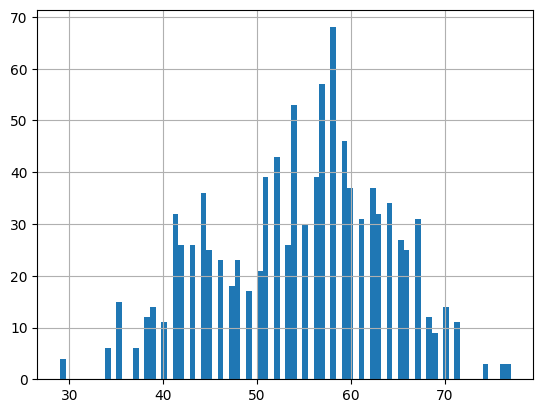

In [ ]:

#Histogrammet visar att de flesta individer i datasetet är mellan 50 och 60 år..
data["age"].hist(bins=80)

Fördelningen av viloplus visar att de flesta värden ligger inom det normala intervallet, men det finns även vissa avvikande värden (outliers). I boxploten kan man dessutom se skillnader mellan personer med och utan sjukdo


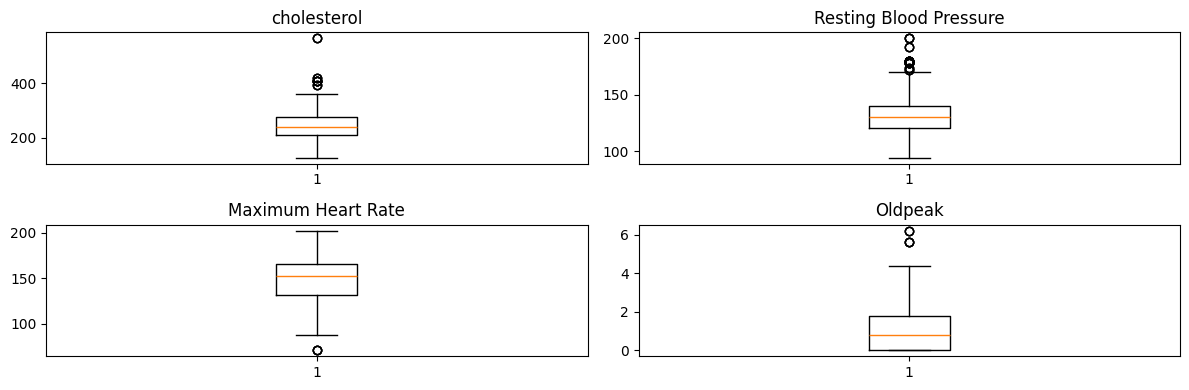

In [32]:

import matplotlib.pyplot as plt

fig, ax=plt.subplots(nrows=2, ncols=2, figsize=(12,4))
ax[0,0].boxplot(data["chol"])
ax[0,0].set_title("cholesterol")

ax[0,1].boxplot(data["trestbps"])
ax[0,1].set_title("Resting Blood Pressure")

ax[1,0].boxplot(data["thalach"])
ax[1,0].set_title("Maximum Heart Rate")


ax[1,1].boxplot(data["oldpeak"])
ax[1,1].set_title("Oldpeak")
plt.tight_layout()

plt.show()


In [33]:
# I detta steg analyseras outliers för att förstå datan bättre.
#Det finns få eller inga outliers i age och thalach, men fler i trestbps och chol.
#Eftersom det är medicinsk data behålls dessa värden och hanteras med robust scaling.
Q1 = data[['oldpeak', 'trestbps', 'chol', 'thalach']].quantile(0.25)
Q3 = data[['oldpeak', 'trestbps', 'chol', 'thalach']].quantile(0.75)    
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = (( data[['oldpeak', 'trestbps', 'chol', 'thalach']] < lower_bound) | ( data[['oldpeak', 'trestbps', 'chol', 'thalach']] > upper_bound)).sum()
print("Outliers in each column:\n", outliers)
print("Lower Bound:\n", lower_bound)
print("\nUpper Bound:\n", upper_bound)


Outliers in each column:
 oldpeak      7
trestbps    30
chol        16
thalach      4
dtype: int64
Lower Bound:
 oldpeak      -2.7
trestbps     90.0
chol        115.0
thalach      81.0
dtype: float64

Upper Bound:
 oldpeak       4.5
trestbps    170.0
chol        371.0
thalach     217.0
dtype: float64


Diagrammet visar inget tydligt samband och stor överlappning mellan grupperna

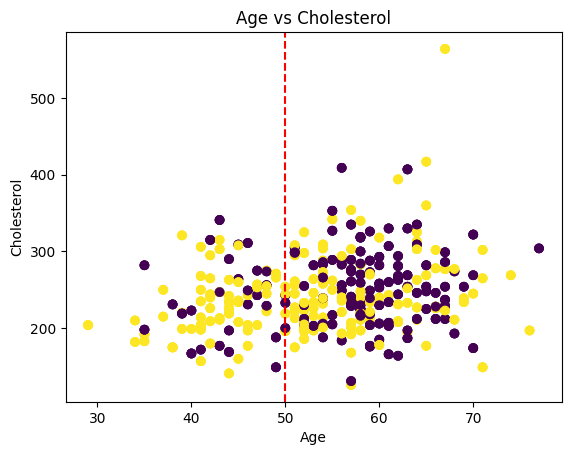

In [26]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(data["age"], data["chol"], c=data["target"])
ax.set(xlabel="Age", ylabel="Cholesterol", title="Age vs Cholesterol")
ax.axvline(x=50, color="red", linestyle="--", label="Age 50")
plt.show()

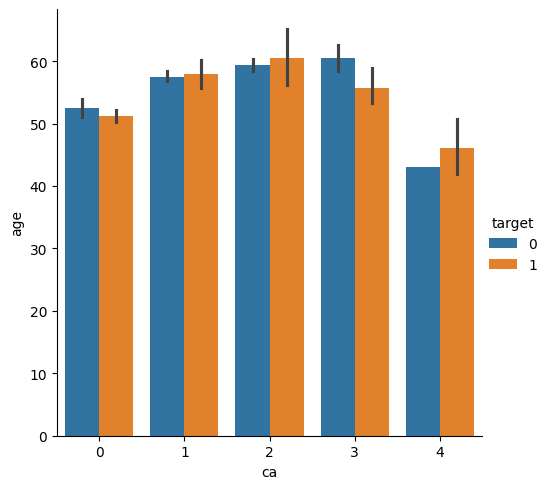

In [26]:
import seaborn as sns
# Diagrammet visar att ca (antal kärl som färgats av fluoroskopi) inte är en tillräckligt tillförlitlig faktor för att förutsäga hjärtsjukdom.
# Vissa individer med 0 kärl kan ändå vara sjuka, därför bör denna variabel analyseras tillsammans med andra faktorer.
sns.catplot(x="ca", y="age", data=data, kind="bar", hue="target");

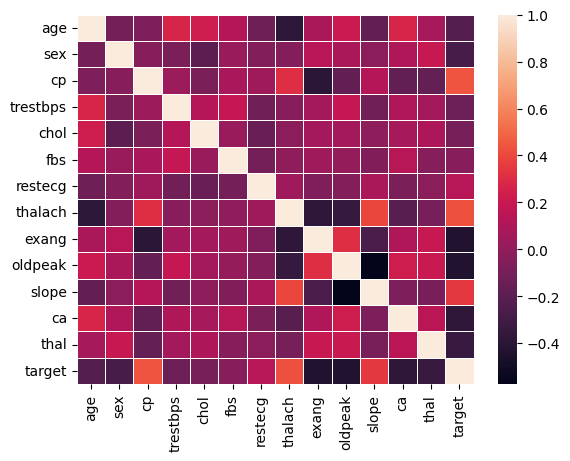

In [10]:
import seaborn as sns
#I heatmap-diagrammet ser man att variablerna ca, oldpeak och exang har en negativ korrelation med target,
# medan cp och thalach har en positiv korrelation.
# Detta visar att variablerna påverkar hjärtsjukdom på olika sätt och bör analyseras tillsammans.
#Dessutom finns tydliga relationer mellan variabler som age och thalach samt exang och oldpeak.
sns.heatmap(data.corr(), linewidths=0.5);  

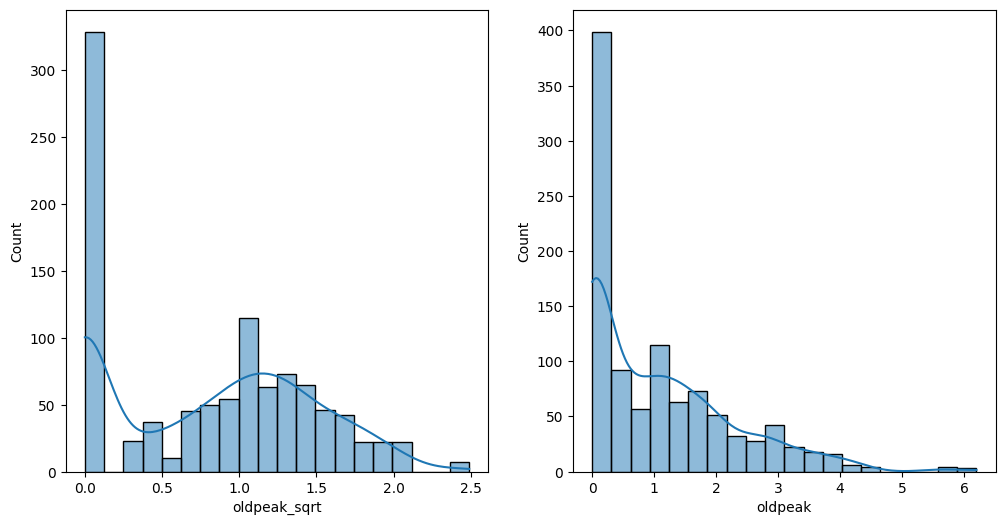

In [8]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
#ِ Nu har jag skapat två histogram för att jämföra fördelningen av oldpeak och dess kvadratrots transformation.
#detta kan hjälpa till att se om en transformation av oldpeak kan göra datan mer normalfördelad, vilket kan vara fördelaktigt för vissa modeller.

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
data["oldpeak_sqrt"] = np.sqrt(data["oldpeak"])
sns.histplot(data["oldpeak_sqrt"], bins=20, kde=True, ax=ax[0])
sns.histplot(data["oldpeak"], bins=20, kde=True, ax=ax[1])
plt.show()

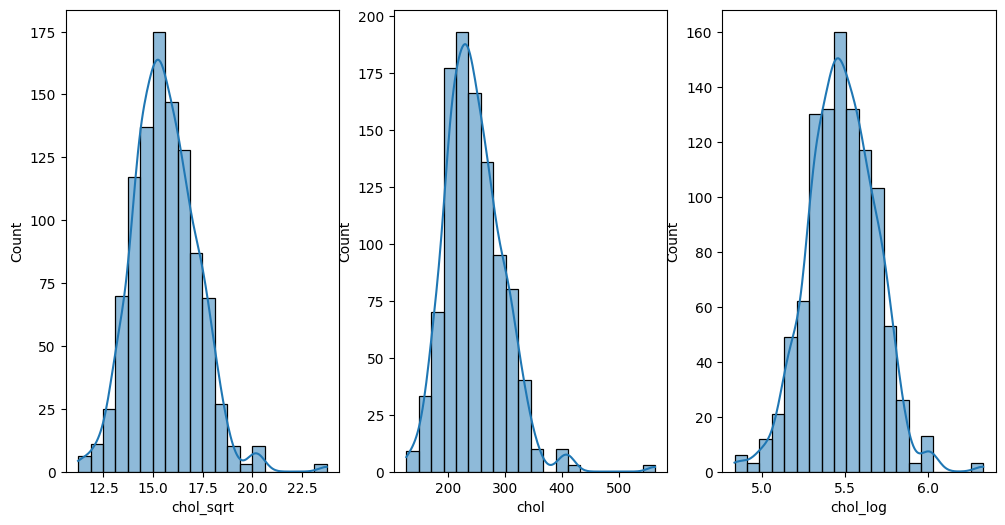

In [10]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
#ِ# Nu har jag skapat tre histogram för att jämföra fördelningen av chol och dess kvadratrots och logaritmiska transformationer
#det visar inte så stor skillnad mellan originaldata och kvadratrots transformation så jag kan använda båda den som finns i datan,

fig, ax = plt.subplots(1, 3, figsize=(12, 6))
data["chol_sqrt"] = np.sqrt(data["chol"])
data["chol_log"] = np.log(data["chol"])
sns.histplot(data["chol_sqrt"], bins=20, kde=True, ax=ax[0])
sns.histplot(data["chol"], bins=20, kde=True, ax=ax[1])
sns.histplot(data["chol_log"], bins=20, kde=True, ax=ax[2])
plt.show()

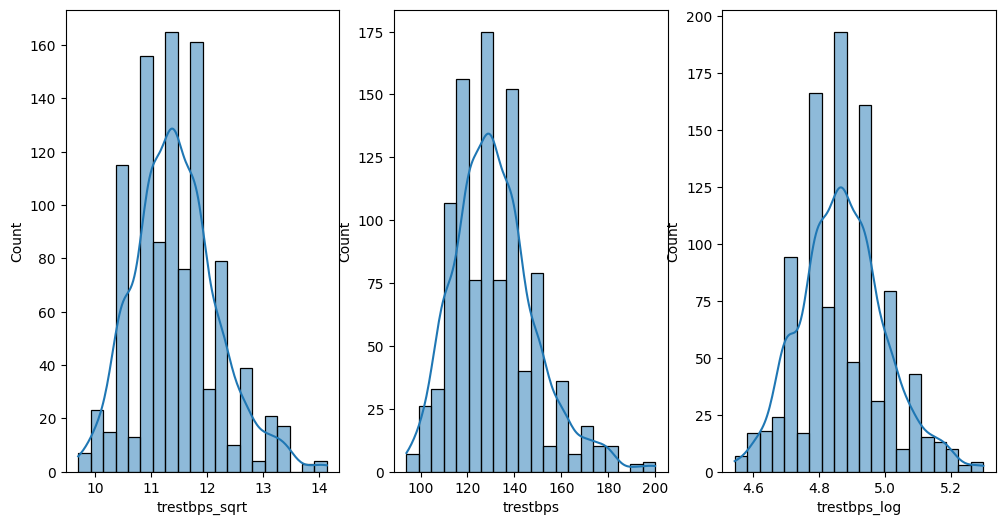

In [11]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
#Variabeln trestbps visar en relativt normalfördelad distribution. 
#Därför anses ingen transformation som log eller sqrt vara nödvändig. 
#Endast skalning med StandardScaler kan användas för att förbättra modellens prestanda.

fig, ax = plt.subplots(1, 3, figsize=(12, 6))
data["trestbps_sqrt"] = np.sqrt(data["trestbps"])
data["trestbps_log"] = np.log(data["trestbps"])
sns.histplot(data["trestbps_sqrt"], bins=20, kde=True, ax=ax[0])
sns.histplot(data["trestbps"], bins=20, kde=True, ax=ax[1])
sns.histplot(data["trestbps_log"], bins=20, kde=True, ax=ax[2])
plt.show()

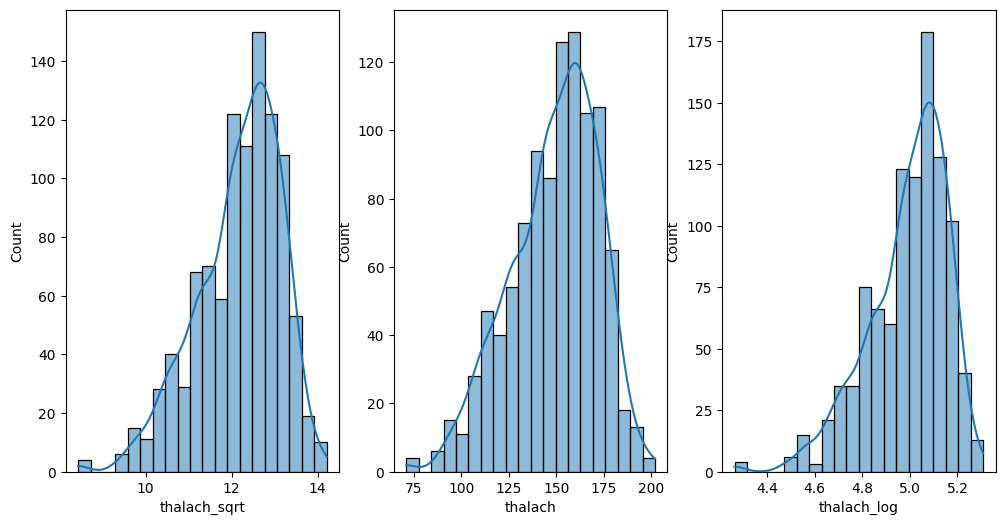

In [12]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
#Variabeln thalach visar en relativt normalfördelad distribution. 
#Därför anses ingen transformation som log eller sqrt vara nödvändig. 
#Endast skalning med StandardScaler kan användas för att förbättra modellens prestanda.

fig, ax = plt.subplots(1, 3, figsize=(12, 6))
data["thalach_sqrt"] = np.sqrt(data["thalach"])
data["thalach_log"] = np.log(data["thalach"])
sns.histplot(data["thalach_sqrt"], bins=20, kde=True, ax=ax[0])
sns.histplot(data["thalach"], bins=20, kde=True, ax=ax[1])
sns.histplot(data["thalach_log"], bins=20, kde=True, ax=ax[2])
plt.show()

In [ ]:

# detta ger  god information om vilka variabler som är mest korrelerade med target,
# vilket kan hjälpa till att välja vilka variabler som ska inkluderas i modellen och hur de kan påverka prediktionerna.
#här ser man att cp och thalach har den starkaste positiva korrelationen med target, medan ca och oldpeak har den starkaste negativa korrelationen.
data.corr()["target"].sort_values(ascending=False)

target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64